In [2]:
import pandas as pd
import numpy as np
path = 'cardekho_dataset.csv'

In [3]:
car_data=pd.read_csv(path)
car_data.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [4]:
fcd=car_data.dropna(axis=0)

In [5]:
car_labels={"name": car_data['car_name'], "km":car_data["km_driven"], "age": car_data['vehicle_age'], "price":car_data['selling_price']}

In [6]:
fcd = fcd.drop('car_name', axis=1)
fcd = fcd.drop('brand', axis=1)
fcd = fcd.drop('model', axis=1)
fcd.head()

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
from sklearn.preprocessing import OneHotEncoder
fcd_encoded=pd.get_dummies(fcd, columns = ['seller_type', 'fuel_type', 'transmission_type'] )
fcd_encoded.columns



Index(['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price', 'seller_type_Dealer',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Electric',
       'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Automatic',
       'transmission_type_Manual'],
      dtype='str')

### Matrix Simplification


In [8]:

fcd_encoded= fcd_encoded.astype(float)  #converts every column to float type
mtrx = fcd_encoded.to_numpy() # pd DataFrame to numpy array
from sympy import Matrix
sym_matrix = Matrix(mtrx[:25])  # just 25 rows remember
rref_matrix, pivot_cols = sym_matrix.rref()
print(pivot_cols)
print(fcd_encoded.columns[[10, 11, 13, 14]]) # redundant ones
print(fcd_encoded.shape)


(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 15, 16, 17)
Index(['seller_type_Trustmark Dealer', 'fuel_type_CNG', 'fuel_type_Electric',
       'fuel_type_LPG'],
      dtype='str')
(15411, 18)


### Structure of the space and remove redundancy


In [9]:
print(fcd_encoded.columns.tolist())

['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Automatic', 'transmission_type_Manual']


In [10]:
fcd_encoded = fcd_encoded.drop(columns = ['fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_LPG', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Electric', 'transmission_type_Automatic', 'Unnamed: 0'])
print(fcd_encoded.shape)
print(fcd_encoded.columns.tolist())
mtrx = fcd_encoded.to_numpy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
mtrx = scaler.fit_transform(mtrx)

(15411, 10)
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'seller_type_Dealer', 'fuel_type_Petrol', 'transmission_type_Manual']


In [11]:

np.linalg.matrix_rank(mtrx)

np.int64(10)

### Orthogonalization

In [12]:
Q, R =np.linalg.qr(fcd_encoded)

In [13]:
print(Q.shape)

(15411, 10)


In [14]:
print(fcd_encoded.columns.tolist())
print(len(fcd_encoded.columns))

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'seller_type_Dealer', 'fuel_type_Petrol', 'transmission_type_Manual']
10


### Projection

In [15]:
# Step 1: Build user preference vector in the exact order of fcd_encoded.columns
print("Feature order used by model:")
print(fcd_encoded.columns.tolist())

# Numeric preferences (one variable per input)
vehicle_age = float(input("Enter preferred vehicle_age: "))
km_driven = float(input("Enter preferred km_driven: "))
mileage = float(input("Enter preferred mileage: "))
engine = float(input("Enter preferred engine (CC): "))
max_power = float(input("Enter preferred max_power: "))
seats = float(input("Enter preferred seats: "))
selling_price = float(input("Enter your budget (selling_price): "))

# One-hot preferences: seller_type
seller_choice = input("Choose seller type (Dealer/Individual): ").strip().lower()
seller_type_Dealer = 1.0 if seller_choice == "dealer" else 0.0

# One-hot preferences: fuel_type
fuel_choice = input("Choose fuel type (Diesel/Petrol): ").strip().lower()
fuel_type_Petrol = 1.0 if fuel_choice == "petrol" else 0.0

# One-hot preferences: transmission_type
trans_choice = input("Choose transmission (Automatic/Manual): ").strip().lower()
transmission_type_Manual = 1.0 if trans_choice == "manual" else 0.0

# Put everything in a feature map (includes all possible columns)
feature_map = {
    "vehicle_age": vehicle_age,
    "km_driven": km_driven,
    "mileage": mileage,
    "engine": engine,
    "max_power": max_power,
    "seats": seats,
    "selling_price": selling_price,
    "seller_type_Dealer": seller_type_Dealer,
    "fuel_type_Petrol": fuel_type_Petrol,
    "transmission_type_Manual": transmission_type_Manual
}

# Final vector: exact same order as fcd_encoded.columns
user_vector = np.array([feature_map[col] for col in fcd_encoded.columns])
user_vector = scaler.transform([user_vector])[0] 
# Scale the user vector using the same scaler fitted on the data
print("\nFinal user_vector shape:", user_vector.shape)
print("Final user_vector:", user_vector)


Feature order used by model:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'seller_type_Dealer', 'fuel_type_Petrol', 'transmission_type_Manual']

Final user_vector shape: (10,)
Final user_vector: [-0.34393331 -0.88375133 -1.12706915 -0.93277159 -0.01368937 -0.40302241
 -0.30753978 -1.27455447  1.00814425  0.51050318]


In [16]:
distances = np.zeros(len(Q))
for i in range (0,len(Q)):
    distances[i] = np.linalg.norm(Q[i] - user_vector)

In [17]:
sorted_indices = np.argsort(distances)
for i in range (0,5):
    print(sorted_indices[i])
    print (car_labels["name"][sorted_indices[i]])

2596
Maruti Alto
7687
Maruti Alto
7191
Maruti Wagon R
3172
Maruti Alto
4264
Mahindra Scorpio


### Prediction / Approximation - already covered


### Pattern Discovery


In [18]:
# Applied eigenvalue decomposition to discover which features drive the most variance in the dataset, revealing the underlying patterns in car pricing and specifications
cov_matrix = np.cov(mtrx.T)  # how every feature varies with every other feature 
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # a 10 X 10 matrix
print(eigenvalues)

[3.45171905 1.75042364 1.27358229 1.06339897 0.85462504 0.596529
 0.51055009 0.26626994 0.15569062 0.0778603 ]


In [19]:
total = sum(eigenvalues)
for i, val in enumerate(eigenvalues):
    print(f"Component {i+1}: {round(val/total * 100, 2)}%")

# Tells how you how much of the "difference between cars" each component explains

Component 1: 34.51%
Component 2: 17.5%
Component 3: 12.73%
Component 4: 10.63%
Component 5: 8.55%
Component 6: 5.96%
Component 7: 5.11%
Component 8: 2.66%
Component 9: 1.56%
Component 10: 0.78%


In [20]:
D = np.diag(eigenvalues)
D


array([[3.45171905, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.75042364, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.27358229, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 1.06339897, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.85462504,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.596529  , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.51055009, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.       

### Final output

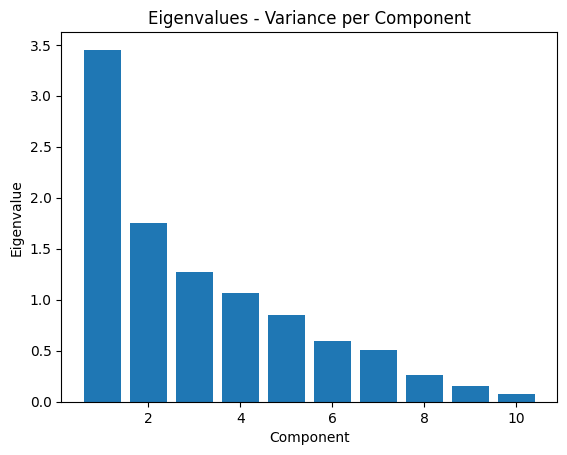

In [21]:
import matplotlib.pyplot as plt
plt.bar(range(1,11), eigenvalues)
plt.title("Eigenvalues - Variance per Component")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()


# So when eigenvalue 1 = 3.45 and eigenvalue 10 = 0.07:

# Component 1 has high variance → cars spread out a lot in that direction → very useful for telling cars apart → important
# Component 10 has low variance → cars are all bunched together in that direction → barely useful → not important

# ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'seller_type_Dealer', 'fuel_type_Petrol', 'transmission_type_Manual']


In [22]:
print("Top 5 Recommended Cars:")
print("------------------------")
for i in range(5):
    print(f"{i+1}. {car_labels["name"][sorted_indices[i]]}|\tKm's: {car_labels["km"][sorted_indices[i]]}\tAge: {car_labels["age"][sorted_indices[i]]}\tPrice: {car_labels["price"][sorted_indices[i]]}")

Top 5 Recommended Cars:
------------------------
1. Maruti Alto|	Km's: 22612	Age: 29	Price: 60000
2. Maruti Alto|	Km's: 54000	Age: 19	Price: 90000
3. Maruti Wagon R|	Km's: 42125	Age: 14	Price: 120000
4. Maruti Alto|	Km's: 58000	Age: 17	Price: 111000
5. Mahindra Scorpio|	Km's: 75823	Age: 14	Price: 310000
